In [3]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

# Load imports from the src directory
sys.path.insert(0, "../..")

from progsnap2.spec.enums import MainTableColumns as Cols
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from progsnap2.analytics.analytics_config import Granularity
from progsnap2.datasets import codeworkout

# Select a dataset by setting the config variable
config = codeworkout.F19


dataset_name, dataset_semester = config.name.split('_')
dataset_root_dir = os.path.join('..', '..', '..', 'sample_data', dataset_name, dataset_semester)
dataset = config.load(dataset_root_dir)

In [5]:
# Shorten some config variables for convenience
problem_id_col = config.primary_problem_grouping_column
timestamp_col = config.primary_timestamp_column

In [6]:
# TODO: Replace this with config files!

# from progsnap2.analytics.preprocessors.edwards import TimeStampToDateTimePreprocessor, ClassSubsetPreprocessor
# from progsnap2.analytics.preprocessors.codebench import YAMLLinkURLPreprocessor, CodeBenchAddParentEventIDs
# from progsnap2.analytics.preprocessors.codeworkout import CodeWorkoutExtractErrorTypesPreprocessor
# from progsnap2.analytics.ps2_dataset import SortPreprocessor, FilterPreprocessor
# from progsnap2.spec.enums import EventType

# data_config_path = None
# problem_id_col = None
# timestamp_col = None
# idle_gap = None
# break_gap = None
# main_table_preprocessors = []
# link_table_preprocessors = []
# submit_event = EventType.Submit
# grades_link_table = "Subject"
# grades_col = None
# start_time = None
# end_time = None
# early_percentage = None
# assignment_ids = None
# compile_error_type_column = Cols.CompileMessageType
# compile_event = EventType.Compile
# compile_error_event = EventType.CompileError
# output_suffix = ''

# falconcode_f21_config = {
#     "config_path": "sample_data_configs/falconcode.yaml",
#     "problem_id_col": Cols.ProblemID,
#     "timestamp_col": Cols.ServerTimestamp,
#     "idle_gap": 5 * 60,
#     "break_gap": 30 * 60,
#     "mt_preprocessing_steps": [
#         FilterPreprocessor(Cols.TermID, "Fall 2021"),
#     ],
#     "early_percentage": 0.25,
# }

# # Note: Only Fall has compilation data; spring has no Run.Program events!
# edwards_s19_config = {
#     "config_path": "sample_data_configs/edwards2019.yaml",
#     "problem_id_col": Cols.AssignmentID,
#     "timestamp_col": Cols.ClientTimestamp,
#     "idle_gap": 30,
#     "break_gap": 3 * 60,
#     "mt_preprocessing_steps": [
#         # Don't need this, since I've done and cached it
#         # AddErrors2021Preprocessor(),
#         TimeStampToDateTimePreprocessor(),
#         # Make sure this comes last so Fall is correct
#         ClassSubsetPreprocessor("Spring"),
#     ],
#     # Compile error info is stored in the Run.Program event itself
#     "compile_event": EventType.RunProgram,
#     "end_time": "2019-02-25 00:00:00",
#     "early_percentage": 0.23,
#     "assignment_ids": ["p4s", "p5s"],  # Only 2 assignments
#     "grades_col": "exam2",
#     "output_suffix": "-s19",
# }

# edwards_f19_config = edwards_s19_config.copy()
# edwards_f19_config["mt_preprocessing_steps"] = edwards_s19_config["mt_preprocessing_steps"].copy()
# edwards_f19_config["mt_preprocessing_steps"][-1] = ClassSubsetPreprocessor("Fall")
# edwards_f19_config["end_time"] = "2019-10-13 00:00:00"
# edwards_f19_config["assignment_ids"] = ["p4f", "p5f"]
# edwards_f19_config["early_percentage"] = 0.42
# edwards_f19_config["output_suffix"] = "-f19"

# edwards2021_config = {
#     "config_path": "sample_data_configs/edwards2021.yaml",
#     "problem_id_col": Cols.AssignmentID,
#     "timestamp_col": Cols.ClientTimestamp,
#     "idle_gap": 30,
#     "break_gap": 3 * 60,
#     "mt_preprocessing_steps": [
#         # Don't need this, since I've done and cached it
#         # AddErrors2021Preprocessor(),
#         TimeStampToDateTimePreprocessor(),
#     ],
#     # Compile error info is stored in the Run.Program event itself
#     "compile_event": EventType.RunProgram,
#     "end_time": "2022-01-01 00:00:00",
#     "early_percentage": 0.4,
#     "assignment_ids": ["Assign6", "Assign7"],  # Only 2 assignments
#     "grades_col": "FinalScore",
# }

# cwo_s19_config = {
#     "config_path": "sample_data_configs/cwo_s19.yaml",
#     "problem_id_col": Cols.ProblemID,
#     "timestamp_col": Cols.ServerTimestamp,
#     "idle_gap": 5 * 60,
#     "break_gap": 30 * 60,
#     "mt_preprocessing_steps": [
#         SortPreprocessor(),
#         CodeWorkoutExtractErrorTypesPreprocessor(),
#     ],
#     "submit_event": EventType.RunProgram,
#     "grades_col": "X-Grade",
#     "early_percentage": 0.33,
# }

# cwo_f19_config = {
#     "config_path": "sample_data_configs/cwo_f19.yaml",
#     "problem_id_col": Cols.ProblemID,
#     "timestamp_col": Cols.ServerTimestamp,
#     "idle_gap": 5 * 60,
#     "break_gap": 30 * 60,
#     "mt_preprocessing_steps": [
#         SortPreprocessor(),
#         CodeWorkoutExtractErrorTypesPreprocessor(),
#     ],
#     "submit_event": EventType.RunProgram,
#     "grades_col": "X-Grade",
#     "early_percentage": 0.25,
# }

# codebench2024_config = {
#     "config_path": "sample_data_configs/codebench2024.yaml",
#     "problem_id_col": Cols.ProblemID,
#     "timestamp_col": Cols.ServerTimestamp,
#     "idle_gap": 30,
#     "break_gap": 3 * 60,
#     "link_preprocessing_steps": [YAMLLinkURLPreprocessor(True)],
#     "mt_preprocessing_steps": [
#         CodeBenchAddParentEventIDs(),
#     ],
#     "grades_link_table": "CourseSubject",
#     "grades_col": "final-grade",
#     "start_time": "2024-09-01 00:00:00",
#     "early_percentage": 0.28,
#     "compile_error_type_col": "ProgramErrorOutput",
#     "compile_event": EventType.Submit,
#     "compile_error_event": EventType.RunTest,
# }

# # config = cwo_f19_config
# # config = cwo_s19_config
# # config = codebench2024_config
# # config = edwards2021_config
# # config = edwards_s19_config
# # config = edwards_f19_config
# config = falconcode_f21_config
# locals().update(config)

In [7]:
main_table = dataset.get_main_table()
main_table.head()

,SubjectID,ToolInstances,ServerTimestamp,ServerTimezone,CourseID,AssignmentID,ProblemID,Attempt,CodeStateID,IsEventOrderingConsistent,EventType,Score,Compile.Result,CompileMessageType,CompileMessageData,EventID,Order,ParentEventID
0,fd8111a7935742d5d198fb6ba2224bf1b772974b7c17e1...,Java 8; CodeWorkout,2019-09-23 15:14:44,0,CS 1,597,13,1,e03c3817ba234c667140a5281960bfc79238ef075b48c7...,True,Run.Program,0.0,NaN,None,NaN,0,0,NaN
1,fd8111a7935742d5d198fb6ba2224bf1b772974b7c17e1...,Java 8; CodeWorkout,2019-09-23 15:14:44,0,CS 1,597,13,1,e03c3817ba234c667140a5281960bfc79238ef075b48c7...,True,Compile,NaN,Error,None,NaN,1,1,0.0
2,fd8111a7935742d5d198fb6ba2224bf1b772974b7c17e1...,Java 8; CodeWorkout,2019-09-23 15:14:44,0,CS 1,597,13,1,e03c3817ba234c667140a5281960bfc79238ef075b48c7...,True,Compile.Error,NaN,NaN,missing return statement,line 18: error: missing return statement,2,2,1.0
3,fd8111a7935742d5d198fb6ba2224bf1b772974b7c17e1...,Java 8; CodeWorkout,2019-09-23 15:15:13,0,CS 1,597,13,2,cdfe99579672f04db808aa7343826bf3c71751dfba129d...,True,Run.Program,0.0,NaN,None,NaN,3,3,NaN
4,fd8111a7935742d5d198fb6ba2224bf1b772974b7c17e1...,Java 8; CodeWorkout,2019-09-23 15:15:13,0,CS 1,597,13,2,cdfe99579672f04db808aa7343826bf3c71751dfba129d...,True,Compile,NaN,Error,None,NaN,4,4,3.0


In [8]:
if config.start_time is not None:
    main_table = main_table[main_table[timestamp_col] >= config.start_time]
if config.end_time is not None:
    main_table = main_table[main_table[timestamp_col] <= config.end_time]

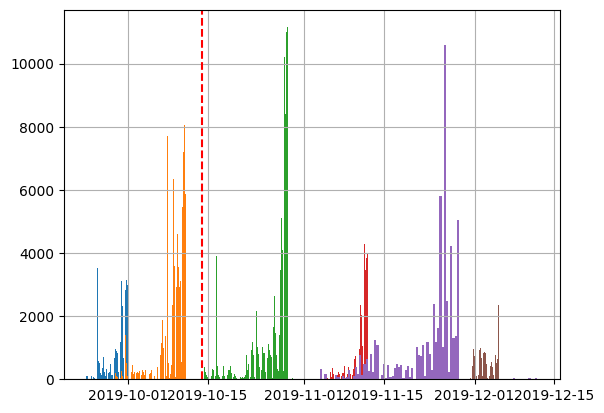

In [9]:
assignment_col = Cols.AssignmentID if Cols.AssignmentID in main_table.columns else problem_id_col
early_timestamp = pd.to_datetime(config.early_time)
if early_timestamp is None:
    print("Warning: No early time cutoff specified")
if Cols.CourseSectionID not in main_table.columns:
    main_table.groupby(assignment_col)[timestamp_col].hist(bins=100)
    if early_timestamp is not None:
        plt.axvline(x=early_timestamp, color='r', linestyle='--', label='Early Time Cutoff')
else:
    classes = main_table[Cols.CourseSectionID].unique()
    classes = classes[~pd.isna(classes)]
    for class_id in classes:
        subset = main_table[main_table[Cols.CourseSectionID] == class_id]
        hist = subset.groupby(assignment_col)[timestamp_col].hist(bins=100)
        plt.title(f"Class {class_id}")
        if early_timestamp is not None:
            plt.axvline(x=early_timestamp, color='r', linestyle='--', label='Early Time Cutoff')
        plt.show()

In [10]:
main_table.AssignmentID.unique()

array([597, 600, 609, 615, 622, 631])

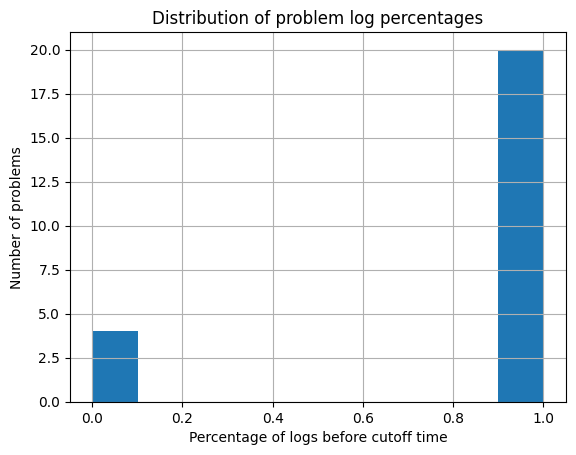

Removing partial problems: Index([128, 40, 38, 37], dtype='int64', name='ProblemID')
This removed 0.05% of data
Semester start 2019-09-23 15:14:44
Semester end 2019-12-11 23:46:40
Early cutoff time 2019-10-14 00:00:00
Early Assignment IDs: [597 600]
Early Problem IDs: [ 13 232 235 234 236   5 233   1   3  12  24 100 101 102  25  28  21  20
  17  22]
Total number of rows: 161703
Percent of logs:  38.94412091961331
Assignments: 2 / 6
Problems: 20 / 60


In [11]:
from progsnap2.analytics.preprocessors.early_cutoff import filter_before_time

data_subset = filter_before_time(main_table, config.early_time, timestamp_col, filter_problems=True, verbose=True)

In [12]:
# We want to analyze each student's attempt at each problem, and we also
# want to analyze data separately from each course section.
grouping_cols = config.attempt_grouping_columns
grouping_cols = [col for col in grouping_cols if col in main_table.columns]
grouping_cols

[<MainTableColumns.SubjectID: 'SubjectID'>,
 <MainTableColumns.AssignmentID: 'AssignmentID'>,
 <MainTableColumns.ProblemID: 'ProblemID'>]

In [13]:
from progsnap2.analytics.metrics.errors import ErrorMetrics

error_results = None

error_metrics = ErrorMetrics(True,
                             compile_message_type_column=config.compile_error_type_column,
                             compile_event=config.compile_event,
                             compile_error_event=config.compile_error_event)

error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)
error_results.head()

C:\Users\twprice\AppData\Local\Temp\ipykernel_5716\3342469648.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)


ErrorQuotient  \
SubjectID                                          AssignmentID ProblemID                  
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 597          1               0.000000   
                                                                3               0.000000   
                                                                5               0.363636   
                                                                12              0.000000   
                                                                13              0.745455   

                                                                           RepeatedErrorDensity  \
SubjectID                                          AssignmentID ProblemID                         
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 597          1                          0.00   
                                                                3                          0.00   
                                                                5                          0.00   
                                                                12                         0.00   
                                                                13                         2.25   

                                                                           FailedCompileCount  
SubjectID                                          AssignmentID ProblemID                      
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 597          1                         0.0  
                                                                3                         1.0  
                                                                5                         2.0  
                                                                12                        0.0  
                                                                13                        5.0

In [14]:
# Distribution of each error metric across students/problems
error_results.describe()

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
count,9741.000000,9741.000000,9750.000000
mean,0.140115,0.502854,2.422359
std,0.233110,1.671906,4.662325
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000
75%,0.242424,0.000000,3.000000
max,1.000000,34.938889,80.000000


In [15]:
# Correlate the metrics
error_results.corr(method="spearman")

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
ErrorQuotient,1.000000,0.828097,0.841371
RepeatedErrorDensity,0.828097,1.000000,0.739706
FailedCompileCount,0.841371,0.739706,1.000000


<Axes: ylabel='Frequency'>

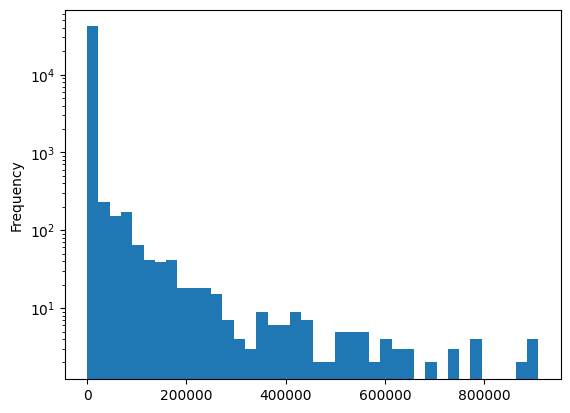

In [16]:
from progsnap2.analytics.metrics.time import TimeMetrics

# Out of curisosity, how far apart are events in this dataset (in seconds)?
diffs = TimeMetrics.get_all_diffs(data_subset, timestamp_col, grouping_cols)
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [17]:
# Determine a gap to be considered idle time or taking a break based
# on the type of dataset. Can confirm with the histogram above if it makes sense
idle_gap = None
break_gap = None
if config.granularity == Granularity.Submission:
    idle_gap = 5 * 60  # 5 minutes
    break_gap = 30 * 60  # 30 minutes
elif config.granularity == Granularity.Edit or config.granularity == Granularity.Keystroke:
    idle_gap = 30
    break_gap = 3 * 60 # 3 minutes
else:
    raise NotImplementedError(f"{config.granularity} granularity has not been determined.")


In [18]:
from progsnap2.analytics.metrics.time import TimeMetrics
time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

time_results = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))
time_results

C:\Users\twprice\AppData\Local\Temp\ipykernel_5716\1574692767.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_results = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))


ActiveTime  \
SubjectID                                          AssignmentID ProblemID               
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 597          1                 0.0   
                                                                3                58.0   
                                                                5                40.0   
                                                                12                0.0   
                                                                13              455.0   
...                                                                               ...   
ffc3b91c3744d275e99f49e105f016732d694a76314d8cd... 600          25               28.0   
                                                                28              111.0   
                                                                100               0.0   
                                                                101             101.0   
                                                                102             551.0   

                                                                           PassiveTime  \
SubjectID                                          AssignmentID ProblemID                
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 597          1                  0.0   
                                                                3                353.0   
                                                                5                  0.0   
                                                                12                 0.0   
                                                                13                 0.0   
...                                                                                ...   
ffc3b91c3744d275e99f49e105f016732d694a76314d8cd... 600          25                 0.0   
                                                                28                 0.0   
                                                                100                0.0   
                                                                101                0.0   
                                                                102                0.0   

                                                                           TotalTime  \
SubjectID                                          AssignmentID ProblemID              
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 597          1                0.0   
                                                                3              411.0   
                                                                5               40.0   
                                                                12               0.0   
                                                                13             455.0   
...                                                                              ...   
ffc3b91c3744d275e99f49e105f016732d694a76314d8cd... 600          25              28.0   
                                                                28             111.0   
                                                                100              0.0   
                                                                101            101.0   
                                                                102            551.0   

                                                                           ActiveTimeAfterCorrect  \
SubjectID                                          AssignmentID ProblemID                           
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 597          1                             0.0   
                                                                3                             0.0   
                                                                5                             0.0   
                                                                12                            0.

In [19]:
time_results.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
count,9750.000000,9750.000000,9750.000000,9750.000000,9750.000000,9750,9274,9750
mean,203.361128,129.870769,333.231897,4.567487,0.173538,2019-10-03 22:38:15.066563840,2019-10-03 22:06:38.720832512,2019-10-04 02:17:45.430563840
min,0.000000,0.000000,0.000000,0.000000,0.000000,2019-09-23 15:14:44,2019-09-23 15:16:48,2019-09-23 15:16:48
25%,0.000000,0.000000,0.000000,0.000000,0.000000,2019-09-30 01:03:36.750000128,2019-09-30 00:59:29.750000128,2019-09-30 02:10:21.750000128
50%,49.000000,0.000000,53.000000,0.000000,0.000000,2019-10-01 02:06:19.500000,2019-10-01 01:56:52.500000,2019-10-01 02:25:50
75%,232.000000,0.000000,299.000000,0.000000,0.000000,2019-10-09 03:26:34.500000,2019-10-09 13:05:38,2019-10-09 14:23:02.249999872
max,10241.000000,6387.000000,16114.000000,2162.000000,8.000000,2019-10-11 03:57:44,2019-10-11 03:57:14,2019-10-11 03:58:55
std,395.408440,452.479555,740.575767,44.160455,0.580955,NaN,NaN,NaN


In [20]:
time_results.corr(method="spearman")

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
ActiveTime,1.000000,0.421542,0.965516,0.073048,0.379134,0.044763,-0.016191,0.084132
PassiveTime,0.421542,1.000000,0.574361,0.063930,0.369571,0.076296,0.020667,0.115278
TotalTime,0.965516,0.574361,1.000000,0.071646,0.388783,0.056085,-0.010979,0.096207
ActiveTimeAfterCorrect,0.073048,0.063930,0.071646,1.000000,0.056267,0.020151,0.047097,0.030257
#Breaks,0.379134,0.369571,0.388783,0.056267,1.000000,0.059829,0.055169,0.159746
StartTime,0.044763,0.076296,0.056085,0.020151,0.059829,1.000000,0.845926,0.986307
FirstCorrectTime,-0.016191,0.020667,-0.010979,0.047097,0.055169,0.845926,1.000000,0.844771
EndTime,0.084132,0.115278,0.096207,0.030257,0.159746,0.986307,0.844771,1.000000


In [21]:
from progsnap2.analytics.metrics.score import SubmissionScoreMetrics
from progsnap2.spec.enums import EventType

score_metrics = SubmissionScoreMetrics(config.submit_event)

subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


C:\Users\twprice\AppData\Local\Temp\ipykernel_5716\3695921909.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


In [22]:
subject_problem_score.head()

Attempts  \
SubjectID                                          AssignmentID ProblemID             
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 597          1                 1   
                                                                3                 4   
                                                                5                 3   
                                                                12                1   
                                                                13                6   

                                                                           FirstCorrect  \
SubjectID                                          AssignmentID ProblemID                 
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 597          1                  True   
                                                                3                 False   
                                                                5                 False   
                                                                12                 True   
                                                                13                False   

                                                                           EverCorrect  \
SubjectID                                          AssignmentID ProblemID                
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 597          1                 True   
                                                                3                 True   
                                                                5                 True   
                                                                12                True   
                                                                13                True   

                                                                           Attempted  \
SubjectID                                          AssignmentID ProblemID              
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 597          1               True   
                                                                3               True   
                                                                5               True   
                                                                12              True   
                                                                13              True   

                                                                           MaxScore  \
SubjectID                                          AssignmentID ProblemID             
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 597          1               1.0   
                                                                3               1.0   
                                                                5               1.0   
                                                                12              1.0   
                                                                13              1.0   

                                                                           MinScore  \
SubjectID                                          AssignmentID ProblemID             
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 597          1               1.0   
                                                                3               0.0   
                                                                5               0.0   
                                                                12              1.0   
                                                                13              0.0   

                                                                           MeanScore  \
SubjectID                                          AssignmentID ProblemID              
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 597          1           1.000000   
                                                                3           0.593750   
       

In [23]:
subject_problem_score.describe()

,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts
count,9750.000000,9750.000000,9750.000000,9750.000000,9750.000000
mean,5.276615,0.983690,0.392008,0.624930,5.406769
std,7.649605,0.097838,0.465592,0.318270,7.802417
min,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,0.000000,0.333333,1.000000
50%,3.000000,1.000000,0.000000,0.563797,3.000000
75%,6.000000,1.000000,1.000000,1.000000,6.000000
max,177.000000,1.000000,1.000000,1.000000,177.000000


In [24]:
all_features = pd.merge(
    time_results.reset_index(),
    subject_problem_score.reset_index(),
    on=grouping_cols,
    how="outer"
)
if error_results is not None:
    all_features = pd.merge(
        all_features,
        error_results.reset_index(),
        on=grouping_cols,
        how="outer"
    )
all_features.head()

,SubjectID,AssignmentID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,...,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,597,1,0.0,0.0,0.0,0.0,0,2019-09-27 12:43:31,2019-09-27 12:43:31,...,True,True,True,1.0,1.0,1.000000,1,0.000000,0.00,0.0
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,597,3,58.0,353.0,411.0,0.0,0,2019-09-27 12:46:46,2019-09-27 12:53:37,...,False,True,True,1.0,0.0,0.593750,4,0.000000,0.00,1.0
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,597,5,40.0,0.0,40.0,0.0,0,2019-09-27 12:35:42,2019-09-27 12:36:22,...,False,True,True,1.0,0.0,0.333333,3,0.363636,0.00,2.0
3,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,597,12,0.0,0.0,0.0,0.0,0,2019-09-27 12:56:42,2019-09-27 12:56:42,...,True,True,True,1.0,1.0,1.000000,1,0.000000,0.00,0.0
4,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,597,13,455.0,0.0,455.0,0.0,0,2019-09-27 11:29:04,2019-09-27 11:36:39,...,False,True,True,1.0,0.0,0.166667,6,0.745455,2.25,5.0


In [25]:
# Some features are NA for some students, e.g. because
# they never got a problem right (no FirstCorrectTime) or
# because they only compiled once and errors metrics are undefined.
all_features.isna().mean()

SubjectID                 0.000000
AssignmentID              0.000000
ProblemID                 0.000000
ActiveTime                0.000000
PassiveTime               0.000000
TotalTime                 0.000000
ActiveTimeAfterCorrect    0.000000
#Breaks                   0.000000
StartTime                 0.000000
FirstCorrectTime          0.048821
EndTime                   0.000000
Attempts                  0.000000
FirstCorrect              0.000000
EverCorrect               0.000000
Attempted                 0.000000
MaxScore                  0.000000
MinScore                  0.000000
MeanScore                 0.000000
TotalAttempts             0.000000
ErrorQuotient             0.000923
RepeatedErrorDensity      0.000923
FailedCompileCount        0.000000
dtype: float64

In [26]:
median_features = all_features.groupby(problem_id_col)[[TimeMetrics.ACTIVE_TIME, SubmissionScoreMetrics.MAX_SCORE]].median()
all_features_with_median = all_features.merge(
    median_features,
    on=problem_id_col,
    suffixes=("", "_median"),
    how="left"
)

# We can calculate a few custom metrics
all_features["AtLeatMedianActiveTime"] = (all_features[TimeMetrics.ACTIVE_TIME] >= all_features_with_median[TimeMetrics.ACTIVE_TIME + "_median"]) + 0
all_features["AtLeatMedianMaxScore"] = (all_features[SubmissionScoreMetrics.MAX_SCORE] >= all_features_with_median[SubmissionScoreMetrics.MAX_SCORE + "_median"]) + 0
all_features["HadEffort"] = all_features["AtLeatMedianActiveTime"] | all_features["AtLeatMedianMaxScore"]
all_features.describe()

,AssignmentID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
count,9750.000000,9750.000000,9750.000000,9750.000000,9750.000000,9750.000000,9750.000000,9750,9274,9750,...,9750.000000,9750.000000,9750.000000,9750.000000,9741.000000,9741.000000,9750.000000,9750.000000,9750.000000,9750.000000
mean,598.481231,83.715487,203.361128,129.870769,333.231897,4.567487,0.173538,2019-10-03 22:38:15.066563840,2019-10-03 22:06:38.720832512,2019-10-04 02:17:45.430563840,...,0.983690,0.392008,0.624930,5.406769,0.140115,0.502854,2.422359,0.575897,0.951179,0.984923
min,597.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2019-09-23 15:14:44,2019-09-23 15:16:48,2019-09-23 15:16:48,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,597.000000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2019-09-30 01:03:36.750000128,2019-09-30 00:59:29.750000128,2019-09-30 02:10:21.750000128,...,1.000000,0.000000,0.333333,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,597.000000,24.500000,49.000000,0.000000,53.000000,0.000000,0.000000,2019-10-01 02:06:19.500000,2019-10-01 01:56:52.500000,2019-10-01 02:25:50,...,1.000000,0.000000,0.563797,3.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
75%,600.000000,232.000000,232.000000,0.000000,299.000000,0.000000,0.000000,2019-10-09 03:26:34.500000,2019-10-09 13:05:38,2019-10-09 14:23:02.249999872,...,1.000000,1.000000,1.000000,6.000000,0.242424,0.000000,3.000000,1.000000,1.000000,1.000000
max,600.000000,236.000000,10241.000000,6387.000000,16114.000000,2162.000000,8.000000,2019-10-11 03:57:44,2019-10-11 03:57:14,2019-10-11 03:58:55,...,1.000000,1.000000,1.000000,177.000000,1.000000,34.938889,80.000000,1.000000,1.000000,1.000000
std,1.499959,92.563833,395.408440,452.479555,740.575767,44.160455,0.580955,NaN,NaN,NaN,...,0.097838,0.465592,0.318270,7.802417,0.233110,1.671906,4.662325,0.494231,0.215504,0.121865


In [27]:
# Let's take the z-score per problem for each numeric feature to
# normalize the features before combining across problems.
all_features_z = all_features.copy()

time_cols = [
    TimeMetrics.START_TIME,
    TimeMetrics.FIRST_CORRECT_TIME,
    TimeMetrics.END_TIME,
]

all_features_z[time_cols] = all_features_z[time_cols].astype('int64') / 1e9
numeric_cols = all_features_z.select_dtypes(include=["number"]).columns
# remove the grouping columns from numeric_cols
numeric_cols = numeric_cols.difference(grouping_cols)
all_features_z[numeric_cols] = all_features_z.groupby(problem_id_col)[numeric_cols].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


In [28]:
all_features_z.head()

,SubjectID,AssignmentID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,597,1,-0.422458,-0.138063,-0.327935,-0.102645,-0.105237,-1.145783,0.090262,...,0.072733,0.961969,0.902587,-0.530196,-0.396623,-0.211922,-0.449093,-1.003052,0.090444,0.045083
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,597,3,-0.363577,0.740400,0.245968,-0.122164,-0.221600,-1.143365,0.231311,...,0.162548,-0.921859,-0.299511,-0.139827,-0.510963,-0.280819,-0.226753,0.996949,0.231385,0.078326
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,597,5,-0.324830,-0.215893,-0.323338,-0.112926,-0.210769,-1.113588,0.143479,...,0.098558,-1.066737,-1.361377,-0.162036,1.385907,-0.301770,0.142720,0.998987,0.143594,0.078087
3,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,597,12,-0.393429,-0.121747,-0.306273,-0.108324,-0.120263,-1.148554,0.063693,...,0.053923,0.803577,0.767098,-0.471177,-0.357986,-0.220609,-0.522053,0.000000,0.063953,0.000000
4,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,597,13,0.187025,-0.401501,-0.161818,-0.174791,-0.432159,-0.661027,0.238626,...,0.150089,-0.499183,-0.849907,-0.279460,1.312518,0.159708,-0.124414,0.998999,0.238680,0.127388


In [29]:
merge_cols = grouping_cols.copy()
merge_cols.remove(Cols.ProblemID)
merge_cols.remove(Cols.AssignmentID)
merge_cols = [col for col in merge_cols if col in all_features_z.columns]

# Take the average across all problems for each student
subject_means = all_features_z.drop([Cols.ProblemID, Cols.AssignmentID], axis=1).groupby(merge_cols).mean()

# Sometimes there are no non-NA values for a student across all problems for a given
# feature and we need to deal with that.

# For EQ and RED having no attempts with a successful compile (and therefore a score)
# should give you the max (worst) value
for col in [ErrorMetrics.ERROR_QUOTIENT, ErrorMetrics.REPEATED_ERROR_DENSITY]:
    max_val = subject_means[col].max()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(max_val)

# But for score metrics, not trying a problem should lead to the minimum value
for col in [SubmissionScoreMetrics.MAX_SCORE, SubmissionScoreMetrics.MEAN_SCORE, SubmissionScoreMetrics.MIN_SCORE]:
    min_val = subject_means[col].min()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(min_val)

subject_means.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,,,,,,,,,,,,,,,,,,,,,
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd4670206aa82503a575dc,-0.297464,0.183327,-0.027601,-0.127728,-0.289159,-0.635549,0.200934,-0.706975,-0.319508,0.400000,...,0.155992,0.067097,0.070329,-0.333956,0.025102,-0.178198,-0.219978,-0.253020,0.201019,0.090237
014604ba54339d4b1266cf78e125053a5ac11dd861ef3cc0b4ed777ed0e2af0a,-0.431143,-0.074818,-0.268796,-0.093847,0.948068,0.304204,0.201065,0.355880,-0.313053,0.400000,...,0.155992,0.092238,0.144573,-0.300600,-0.579292,-0.298961,-0.452761,-0.253008,0.201019,0.090237
01e96e066eff2e82627dac0493737be2de9bd2f50d6d498bb6420906c7164c05,-0.222163,-0.026535,-0.125751,-0.122669,-0.278372,-0.227894,-0.404033,-0.277828,-0.219626,0.333333,...,-0.127872,-0.043900,0.046962,-0.235674,-0.090475,-0.176775,-0.249939,0.052096,-0.403985,-0.422137
03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b08b27be1fb7638cc466,0.125571,0.439323,0.352662,0.046516,0.351336,-0.169989,0.064650,-0.127258,-0.020818,0.500000,...,0.095526,0.597959,0.553948,0.014240,-0.389748,-0.106134,-0.114804,-0.352904,0.064660,0.090237
0461c96c9cc0058f709704605f24136f373ba4e9ac083a1157d0976f1b6e8419,0.316437,-0.225456,0.015194,-0.125199,0.089202,-2.419324,0.080201,-2.357032,-0.079148,0.157895,...,0.067430,-0.042656,0.096680,-0.098390,-0.200984,-0.135827,-0.235606,0.417737,0.080486,-0.072762


In [30]:
# We can also take the sum of features across problems, which treats
# missing problems differently than the mean.
subject_totals = all_features_z.drop([Cols.ProblemID, Cols.AssignmentID], axis=1).groupby(merge_cols).sum()
subject_totals.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,,,,,,,,,,,,,,,,,,,,,
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd4670206aa82503a575dc,-5.949270,3.666547,-0.552026,-2.554559,-5.783176,-12.710979,4.018687,-14.139494,-6.390163,8,...,3.119846,1.341946,1.406585,-6.679112,0.502043,-3.563962,-4.399563,-5.060409,4.020378,1.804735
014604ba54339d4b1266cf78e125053a5ac11dd861ef3cc0b4ed777ed0e2af0a,-8.622868,-1.496361,-5.375911,-1.876934,18.961353,6.084089,4.021296,7.117600,-6.261064,8,...,3.119846,1.844767,2.891450,-6.012003,-11.585841,-5.979215,-9.055220,-5.060168,4.020378,1.804735
01e96e066eff2e82627dac0493737be2de9bd2f50d6d498bb6420906c7164c05,-3.998939,-0.477628,-2.263522,-2.208047,-5.010698,-4.102084,-7.272590,-5.000907,-3.953277,6,...,-2.301694,-0.790200,0.845325,-4.242139,-1.628552,-3.181947,-4.498903,0.937725,-7.271721,-7.598475
03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b08b27be1fb7638cc466,2.511418,8.786464,7.053244,0.930318,7.026711,-3.399786,1.293008,-2.545156,-0.416369,10,...,1.910527,11.959171,11.078960,0.284807,-7.794968,-2.122688,-2.296089,-7.058075,1.293200,1.804735
0461c96c9cc0058f709704605f24136f373ba4e9ac083a1157d0976f1b6e8419,6.012307,-4.283657,0.288680,-2.378775,1.694845,-45.967163,1.523825,-44.783606,-1.503808,3,...,1.281171,-0.810455,1.836918,-1.869414,-3.818689,-2.580711,-4.476514,7.937003,1.529243,-1.382475


In [31]:
# Lets merge the means and totals into a single DataFrame
subject_features = pd.merge(
    subject_means.reset_index(),
    subject_totals.reset_index(),
    on=merge_cols,
    how="outer",
    suffixes=('_mean', '_sum')
)
subject_features.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,-0.297464,0.183327,-0.027601,-0.127728,-0.289159,-0.635549,0.200934,-0.706975,-0.319508,...,3.119846,1.341946,1.406585,-6.679112,0.502043,-3.563962,-4.399563,-5.060409,4.020378,1.804735
1,014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...,-0.431143,-0.074818,-0.268796,-0.093847,0.948068,0.304204,0.201065,0.355880,-0.313053,...,3.119846,1.844767,2.891450,-6.012003,-11.585841,-5.979215,-9.055220,-5.060168,4.020378,1.804735
2,01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...,-0.222163,-0.026535,-0.125751,-0.122669,-0.278372,-0.227894,-0.404033,-0.277828,-0.219626,...,-2.301694,-0.790200,0.845325,-4.242139,-1.628552,-3.181947,-4.498903,0.937725,-7.271721,-7.598475
3,03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...,0.125571,0.439323,0.352662,0.046516,0.351336,-0.169989,0.064650,-0.127258,-0.020818,...,1.910527,11.959171,11.078960,0.284807,-7.794968,-2.122688,-2.296089,-7.058075,1.293200,1.804735
4,0461c96c9cc0058f709704605f24136f373ba4e9ac083a...,0.316437,-0.225456,0.015194,-0.125199,0.089202,-2.419324,0.080201,-2.357032,-0.079148,...,1.281171,-0.810455,1.836918,-1.869414,-3.818689,-2.580711,-4.476514,7.937003,1.529243,-1.382475


In [32]:
subject_features.isna().mean()[subject_features.isna().mean() != 0]

Series([], dtype: float64)

In [33]:
# No feature should be NA at this point
assert subject_features.isna().mean().mean() == 0

In [34]:
# Take one last z-score across all students for each numeric feature
# This makes means and sums more comparable across students
subject_feautres_z = subject_features.copy()
numeric_cols = subject_feautres_z.select_dtypes(include=["number"]).columns
numeric_cols = numeric_cols.difference(merge_cols)
subject_feautres_z[numeric_cols] = subject_feautres_z[numeric_cols].apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1), axis=0)
subject_feautres_z.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,-0.681976,0.487998,-0.073142,-0.350969,-0.674883,-0.804204,0.394493,-0.887989,-0.681731,...,0.379840,0.153132,0.154288,-0.742688,0.064521,-0.497748,-0.499911,-0.695940,0.486073,0.353306
1,014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...,-0.987288,-0.215226,-0.642284,-0.260234,2.242589,0.362448,0.394703,0.423574,-0.667995,...,0.379840,0.210509,0.317162,-0.668508,-1.488972,-0.835065,-1.028922,-0.695907,0.486073,0.353306
2,01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...,-0.509997,-0.083696,-0.304745,-0.337422,-0.649447,-0.298122,-0.583139,-0.358422,-0.469185,...,-0.280230,-0.090171,0.092723,-0.471707,-0.209296,-0.444395,-0.511199,0.128962,-0.879168,-1.487525
3,03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...,0.284194,1.185366,0.824161,0.115663,0.835450,-0.226237,0.174257,-0.172618,-0.046126,...,0.232606,1.364680,1.215246,0.031669,-1.001782,-0.296458,-0.260899,-0.970672,0.156351,0.353306
4,0461c96c9cc0058f709704605f24136f373ba4e9ac083a...,0.720114,-0.625583,0.027841,-0.344196,0.217321,-3.018662,0.199387,-2.924160,-0.170250,...,0.155982,-0.092482,0.201491,-0.207871,-0.490765,-0.360426,-0.508655,1.091548,0.184889,-0.270642


In [35]:
# Get the grades to compare features to
grades = dataset.get_link_table(config.grades_link_table_name)
grades.head()

,SubjectID,X-Grade
0,80b79645be384d8162597a76b28062cd35ea1019db9344...,48.50
1,f2c0c481d6d6af0b83c418cd9a25d31dc1ffd303019b7c...,87.15
2,c24802aafcbbb5d0d9f4ff58778800955e3c56280ac703...,44.00
3,b83f22b6c073f282fc8e9556f47e3cb0ecb74d95097383...,52.03
4,fa57bd66cb6354a6d8af1e7b47b28589e586bf1303a908...,48.00


In [36]:
grades.rename(columns={
    config.final_grade_column: "Grade",
    # Edwards 2019 calls it Group
    # "Group": Cols.CourseSectionID,
    },
inplace=True)

# Drop 0 grades, since they're likely students who skipped the test
print(f"Dropping {grades[grades['Grade'] <= 0].shape[0]} rows with 0 grades")
grades = grades[grades["Grade"] > 0]

Dropping 12 rows with 0 grades


In [37]:
grade_merge_cols = [col for col in merge_cols if col in grades.columns]
print(f"Merging on columns: {grade_merge_cols}")

subject_feautres_labeled = pd.merge(
    subject_feautres_z,
    grades[grade_merge_cols + ["Grade"]],
    on=grade_merge_cols,
    how="inner",
)

Merging on columns: [<MainTableColumns.SubjectID: 'SubjectID'>]


In [38]:
print(subject_features.shape)
subject_feautres_labeled.head()

(506, 45)


,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum,Grade
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,-0.681976,0.487998,-0.073142,-0.350969,-0.674883,-0.804204,0.394493,-0.887989,-0.681731,...,0.153132,0.154288,-0.742688,0.064521,-0.497748,-0.499911,-0.695940,0.486073,0.353306,59.38
1,014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...,-0.987288,-0.215226,-0.642284,-0.260234,2.242589,0.362448,0.394703,0.423574,-0.667995,...,0.210509,0.317162,-0.668508,-1.488972,-0.835065,-1.028922,-0.695907,0.486073,0.353306,97.00
2,01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...,-0.509997,-0.083696,-0.304745,-0.337422,-0.649447,-0.298122,-0.583139,-0.358422,-0.469185,...,-0.090171,0.092723,-0.471707,-0.209296,-0.444395,-0.511199,0.128962,-0.879168,-1.487525,59.46
3,03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...,0.284194,1.185366,0.824161,0.115663,0.835450,-0.226237,0.174257,-0.172618,-0.046126,...,1.364680,1.215246,0.031669,-1.001782,-0.296458,-0.260899,-0.970672,0.156351,0.353306,73.05
4,0461c96c9cc0058f709704605f24136f373ba4e9ac083a...,0.720114,-0.625583,0.027841,-0.344196,0.217321,-3.018662,0.199387,-2.924160,-0.170250,...,-0.092482,0.201491,-0.207871,-0.490765,-0.360426,-0.508655,1.091548,0.184889,-0.270642,73.13


In [39]:
subject_feautres_labeled.groupby(grade_merge_cols).Grade.count().describe()

count    494.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: Grade, dtype: float64

In [40]:
assert subject_feautres_labeled.groupby(grade_merge_cols).Grade.count().max() == 1

In [41]:

out_dir = os.path.join("..", "..", "..", "analysis", "features")
print(len(subject_feautres_labeled))
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
subject_feautres_labeled.to_csv(os.path.join(out_dir, f"{config.name}.csv"), index=False)

494
